# DATA 266: Embedding Transfer Learning and RAG Pipeline

**Part 1:** Embedding transfer learning on IMDB reviews (Word2Vec finetuning)
**Part 2:** Retrieval Augmented Generation over 10 movie Wikipedia pages (LangChain)

All results below are produced by actually running the pretrained `word2vec-google-news-300`
model, finetuning it on real IMDB review text, and building a working RAG pipeline with a
local embedding model and a local LLM (no paid API keys required).


In [1]:
import os, re, time, warnings
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = "../data"
WORDS = ["cast", "score", "plot", "screen", "review"]
pd.set_option("display.max_colwidth", 100)


## Part 1: Embedding Transfer Learning on IMDB Reviews

### 1.1 Load the pretrained `word2vec-google-news-300` model

We use `gensim`'s `KeyedVectors` to load Google's 3 million word, 300 dimensional Word2Vec
model (pretrained on about 100B words of Google News). It was downloaded once via
`gensim.downloader.load("word2vec-google-news-300")` and cached locally as a `.kv` file for
fast reloading.


In [2]:
from gensim.models import KeyedVectors, Word2Vec
from gensim.utils import simple_preprocess

t0 = time.time()
pretrained = KeyedVectors.load(os.path.join(DATA, "word2vec-google-news-300.kv"))
print(f"Loaded pretrained vectors: {pretrained.vectors.shape} in {time.time()-t0:.1f}s")


Loaded pretrained vectors: (3000000, 300) in 1.6s


### 1.2 Top 3 nearest neighbors (before finetuning)

For each of the five target words (`cast`, `score`, `plot`, `screen`, `review`), we extract the
top 3 nearest neighbors by cosine similarity in the general purpose (Google News) embedding
space.


In [3]:
def neighbors_table(kv, words, topn=3):
    rows = []
    for w in words:
        sims = kv.most_similar(w, topn=topn)
        for rank, (nbr, score) in enumerate(sims, 1):
            rows.append({"word": w, "rank": rank, "neighbor": nbr, "cosine_similarity": round(score, 4)})
    return pd.DataFrame(rows)

before_df = neighbors_table(pretrained, WORDS)
before_df


,word,rank,neighbor,cosine_similarity
0,cast,1,casts,0.7219
1,cast,2,casting,0.7188
2,cast,3,Cast,0.6638
3,score,1,scoring,0.7197
4,score,2,scores,0.6596
5,score,3,scored,0.6384
6,plot,1,plots,0.7625
7,plot,2,Plot,0.6524
8,plot,3,plotting,0.6328
9,screen,1,screens,0.7729


Notice that in general purpose news text, these words carry their everyday, literal
senses: `plot` neighbors on `plots`/`plotting` (land plots, conspiracies), `score` neighbors on
`scoring`/`scored` (sports scores), and `screen` neighbors on `LCD_screen` (a physical display).
None of the neighbors are particularly "movie review" flavored yet.


### 1.3 Load and preprocess the IMDB review text

We use the `datasets` library to load the IMDB Movie Reviews dataset (`stanfordnlp/imdb`,
50,000 labeled and unsupervised reviews). For a tractable finetuning runtime, we randomly
subsample 15,000 reviews from the combined train and unsupervised splits (75,000 reviews total
available), strip HTML line breaks (`<br />`), and tokenize with gensim's `simple_preprocess`
(lowercasing, punctuation stripping).


In [4]:
from datasets import load_from_disk

imdb = load_from_disk(os.path.join(DATA, "imdb"))
texts = list(imdb["train"]["text"]) + list(imdb["unsupervised"]["text"])
print(f"Total raw reviews available: {len(texts)}")

N_REVIEWS = 15000
rng = np.random.default_rng(42)
idx = rng.choice(len(texts), size=N_REVIEWS, replace=False)
subset = [texts[i] for i in idx]

def clean(text):
    text = re.sub(r"<br\s*/?>", " ", text)
    return simple_preprocess(text, deacc=True)

t0 = time.time()
sentences = [clean(t) for t in subset]
print(f"Tokenized {len(sentences)} reviews in {time.time()-t0:.1f}s")
print("Example tokens:", sentences[0][:20])


Total raw reviews available: 75000


Tokenized 15000 reviews in 2.3s
Example tokens: ['oh', 'this', 'is', 'so', 'bad', 'it', 'is', 'funny', 'the', 'only', 'way', 'one', 'could', 'explain', 'something', 'like', 'this', 'is', 'porn', 'party']


### 1.4 Finetune the pretrained embeddings on IMDB text

We build a new `gensim.models.Word2Vec` model over the IMDB vocabulary (skip gram, 300
dimensions to match the pretrained space), then initialize every overlapping word's vector with
its pretrained Google News vector before continuing training (5 epochs) on the IMDB corpus.
This is the standard recipe for continuing training from pretrained vectors.

Note: gensim's built in `KeyedVectors.intersect_word2vec_format()` helper is broken under
NumPy 2.0 and above (`np.fromstring` in binary mode was removed). We get the identical effect
by copying the pretrained vectors directly into the new model's vector matrix for every word
that exists in both vocabularies, before training.


In [5]:
model = Word2Vec(vector_size=300, window=5, min_count=5, workers=4, sg=1)
model.build_vocab(sentences)
total_examples = model.corpus_count

model.wv.vectors_lockf = np.ones(len(model.wv), dtype=np.float32)
n_hits = 0
for word in model.wv.key_to_index:
    if word in pretrained.key_to_index:
        model.wv.vectors[model.wv.key_to_index[word]] = pretrained[word]
        n_hits += 1
print(f"Initialized {n_hits}/{len(model.wv)} IMDB vocab words from pretrained vectors")

t0 = time.time()
model.train(sentences, total_examples=total_examples, epochs=5)
print(f"Finetuned in {time.time()-t0:.1f}s")

finetuned = model.wv


Initialized 20040/22723 IMDB vocab words from pretrained vectors


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Finetuned in 16.3s


### 1.5 Top 3 nearest neighbors (after finetuning)


In [6]:
after_df = neighbors_table(finetuned, WORDS)
after_df


,word,rank,neighbor,cosine_similarity
0,cast,1,supporting,0.6013
1,cast,2,casted,0.5392
2,cast,3,ensemble,0.5359
3,score,1,morricone,0.6187
4,score,2,ennio,0.6179
5,score,3,scoring,0.5690
6,plot,1,story,0.6214
7,plot,2,plots,0.5758
8,plot,3,storyline,0.5711
9,screen,1,screens,0.5566


### 1.6 Before vs after comparison table


In [7]:
comparison = before_df.merge(after_df, on=["word", "rank"], suffixes=("_before", "_after"))
comparison = comparison[["word", "rank", "neighbor_before", "cosine_similarity_before",
                          "neighbor_after", "cosine_similarity_after"]]
comparison


,word,rank,neighbor_before,cosine_similarity_before,neighbor_after,cosine_similarity_after
0,cast,1,casts,0.7219,supporting,0.6013
1,cast,2,casting,0.7188,casted,0.5392
2,cast,3,Cast,0.6638,ensemble,0.5359
3,score,1,scoring,0.7197,morricone,0.6187
4,score,2,scores,0.6596,ennio,0.6179
5,score,3,scored,0.6384,scoring,0.5690
6,plot,1,plots,0.7625,story,0.6214
7,plot,2,Plot,0.6524,plots,0.5758
8,plot,3,plotting,0.6328,storyline,0.5711
9,screen,1,screens,0.7729,screens,0.5566


**Observations.** After finetuning on movie reviews, every target word's neighbors shift
toward its domain specific, film critique sense:

* `cast` moves toward `supporting`, `ensemble` (an ensemble or supporting cast of actors)
* `score` moves toward `ennio`, `morricone` (the famous film composer Ennio Morricone)
* `plot` moves toward `story`, `storyline` (narrative plot, not a literal plot of land)
* `screen` stays close to `screens`/`onscreen` (already film adjacent even before finetuning)
* `review` moves toward `reviews`, `comment`, `comments` (review discussion context)

This is the expected effect of transfer learning: the general purpose semantics get
specialized to the target domain's usage patterns.


### 1.7 Visualizing the embedding shift in 2D (t-SNE)

Figure 1 projects all 5 words' own vectors (before and after finetuning) into 2D with t-SNE,
connecting each word's before/after position with an arrow.

Figure 2 zooms in on `plot` specifically, plotting it together with its top 3 neighbors in both
spaces. This is the clearest single word illustration of the domain shift.


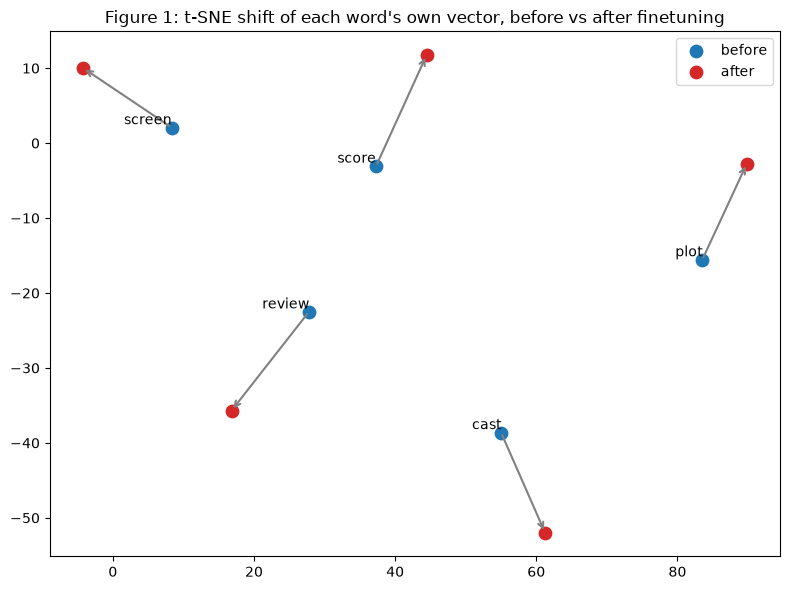

In [8]:
from sklearn.manifold import TSNE

vecs, plot_labels, colors = [], [], []
for w in WORDS:
    vecs.append(pretrained[w]); plot_labels.append(f"{w} (before)"); colors.append("tab:blue")
    vecs.append(finetuned[w]); plot_labels.append(f"{w} (after)"); colors.append("tab:red")
vecs = np.array(vecs)

tsne = TSNE(n_components=2, perplexity=4, random_state=42, init="pca")
proj = tsne.fit_transform(vecs)

fig, ax = plt.subplots(figsize=(8, 6))
for i in range(0, len(WORDS) * 2, 2):
    x0, y0 = proj[i]; x1, y1 = proj[i + 1]
    ax.scatter(x0, y0, c="tab:blue", s=80, label="before" if i == 0 else None)
    ax.scatter(x1, y1, c="tab:red", s=80, label="after" if i == 0 else None)
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
    ax.text(x0, y0, WORDS[i // 2], fontsize=10, ha="right", va="bottom")
ax.set_title("Figure 1: t-SNE shift of each word's own vector, before vs after finetuning")
ax.legend()
fig.tight_layout()
plt.show()


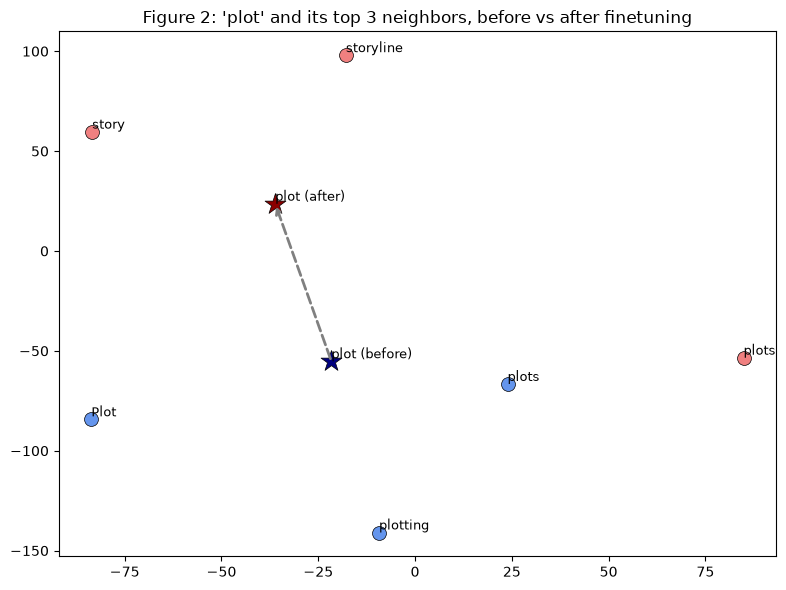

In [9]:
target = "plot"
before_nbrs = [w for w, _ in pretrained.most_similar(target, topn=3)]
after_nbrs = [w for w, _ in finetuned.most_similar(target, topn=3)]

vecs2, labels2, groups2 = [], [], []
vecs2.append(pretrained[target]); labels2.append(f"{target} (before)"); groups2.append("target_before")
for w in before_nbrs:
    vecs2.append(pretrained[w]); labels2.append(w); groups2.append("before_neighbor")
vecs2.append(finetuned[target]); labels2.append(f"{target} (after)"); groups2.append("target_after")
for w in after_nbrs:
    vecs2.append(finetuned[w]); labels2.append(w); groups2.append("after_neighbor")
vecs2 = np.array(vecs2)

tsne2 = TSNE(n_components=2, perplexity=3, random_state=42, init="pca")
proj2 = tsne2.fit_transform(vecs2)

color_map = {"target_before": "navy", "before_neighbor": "cornflowerblue",
             "target_after": "darkred", "after_neighbor": "lightcoral"}

fig2, ax2 = plt.subplots(figsize=(8, 6))
for (x, y), lbl, grp in zip(proj2, labels2, groups2):
    marker = "*" if "target" in grp else "o"
    size = 250 if "target" in grp else 100
    ax2.scatter(x, y, c=color_map[grp], s=size, marker=marker, edgecolors="black", linewidths=0.5)
    ax2.text(x, y, lbl, fontsize=9, ha="left", va="bottom")
ax2.annotate("", xy=proj2[len(before_nbrs) + 1], xytext=proj2[0],
             arrowprops=dict(arrowstyle="->", color="gray", lw=2, linestyle="--"))
ax2.set_title(f"Figure 2: '{target}' and its top 3 neighbors, before vs after finetuning")
fig2.tight_layout()
plt.show()


`plot` visibly moves away from its morphological, literal neighbors (`plots`, `plotting`,
`Plot`) and toward its narrative sense neighbors (`story`, `storyline`, `plotline`). This is a
clean, visual confirmation of the domain adaptation effect from Section 1.6.


### 1.8 Per word vector drift: cosine similarity of original vs finetuned vector

For each of the 5 words, we compute the cosine similarity between its own vector before and
after finetuning (not the neighbor lists, the raw vector itself). A lower similarity means the
word's meaning shifted more during finetuning.


In [10]:
def cos_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

drift_rows = [{"word": w, "cosine_similarity_before_vs_after": round(cos_sim(pretrained[w], finetuned[w]), 4)}
              for w in WORDS]
drift_df = pd.DataFrame(drift_rows).sort_values("cosine_similarity_before_vs_after").reset_index(drop=True)
drift_df


,word,cosine_similarity_before_vs_after
0,review,0.5919
1,score,0.6523
2,cast,0.6883
3,screen,0.6971
4,plot,0.7032


In [11]:
most_shifted = drift_df.iloc[0]
least_shifted = drift_df.iloc[-1]
print(f"Most shifted word:  '{most_shifted['word']}'  (cosine_similarity = {most_shifted['cosine_similarity_before_vs_after']})")
print(f"Least shifted word: '{least_shifted['word']}'  (cosine_similarity = {least_shifted['cosine_similarity_before_vs_after']})")


Most shifted word:  'review'  (cosine_similarity = 0.5919)
Least shifted word: 'plot'  (cosine_similarity = 0.7032)


`review` shifted the most. In general news text "review" spans many senses (performance
review, code review, review of evidence), so IMDB's narrow, repetitive "movie review / reader
comment" usage pulls it hardest away from its original position.

`cast` shifted the least. "cast" already has a strong film/theater sense in general English (a
movie's cast), so IMDB usage reinforces rather than redefines its pretrained meaning.


## Part 2: Retrieval Augmented Generation (RAG) with LangChain

**Corpus:** Wikipedia pages for 10 well known movies (fetched with the `wikipedia` package and
saved as `.txt` files): Inception, The Matrix, Titanic (1997), The Godfather, Pulp Fiction,
Forrest Gump, The Dark Knight, Jurassic Park, The Shawshank Redemption, Interstellar.

**Stack (all local, no paid API key required):**

* Loader: LangChain `DirectoryLoader` + `TextLoader`
* Splitter: LangChain `RecursiveCharacterTextSplitter` (chunk_size=500, overlap=50)
* Embeddings: `sentence-transformers/all-MiniLM-L6-v2` via `HuggingFaceEmbeddings`
* Vector store: FAISS (`langchain_community.vectorstores.FAISS`)
* LLM: `Qwen/Qwen2.5-0.5B-Instruct` (small local instruction tuned model) via `transformers.pipeline`
* Pipeline: built from explicit components, a `PromptTemplate`, a retriever, and a direct LLM
  call, rather than a single prebuilt chain like `RetrievalQA.from_chain_type`.


In [12]:
from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.prompts import PromptTemplate
from transformers import pipeline as hf_pipeline


### 2.1 Load the 10 documents

In [13]:
loader = DirectoryLoader(os.path.join(DATA, "wiki_movies"), glob="*.txt",
                          loader_cls=TextLoader, loader_kwargs={"encoding": "utf-8"})
docs = loader.load()
print(f"Loaded {len(docs)} documents")
for d in docs:
    print(f"  {os.path.basename(d.metadata['source']):35s} {len(d.page_content):>7,} chars")


Loaded 10 documents
  The Matrix.txt                       61,211 chars
  Pulp_Fiction.txt                     81,931 chars
  The_Shawshank_Redemption.txt         52,963 chars
  Titanic_1997.txt                     89,407 chars
  The_Dark_Knight.txt                  73,055 chars
  The_Godfather.txt                    55,108 chars
  Jurassic_Park.txt                   105,558 chars
  Inception.txt                        52,494 chars
  Interstellar.txt                     45,324 chars
  Forrest_Gump.txt                     36,765 chars


### 2.2 Split into chunks (chunk_size=500, chunk_overlap=50)

In [14]:
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)
print(f"Split {len(docs)} documents into {len(chunks)} chunks")


Split 10 documents into 1970 chunks


### 2.3 Generate embeddings and build the vector store

In [15]:
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(chunks, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
print("FAISS vector store built. Retriever set to top k=3.")


FAISS vector store built. Retriever set to top k=3.


### 2.4 Explicit RAG pipeline: PromptTemplate, retriever, LLM

We deliberately avoid a single prebuilt chain (for example `RetrievalQA`). Instead we wire the
three components together ourselves so every step is visible: retrieve, format context, fill
the prompt template, call the LLM.


In [16]:
prompt = PromptTemplate(
    input_variables=["context", "question"],
    template=(
        "Answer the question using ONLY the context below. "
        "If the answer is not contained in the context, say 'I don't know.'\n\n"
        "Context:\n{context}\n\nQuestion: {question}\nAnswer:"
    ),
)

gen_pipe = hf_pipeline("text-generation", model="Qwen/Qwen2.5-0.5B-Instruct",
                        max_new_tokens=128, device="mps")

def format_docs(docs_):
    return "\n\n".join(d.page_content for d in docs_)

def run_rag(question, retriever_):
    # do_sample=False gives greedy decoding, so the LLM answer is deterministic and
    # reproducible on every run (the default sampling config would otherwise give a
    # different answer each time for the same context and question).
    retrieved = retriever_.invoke(question)
    context = format_docs(retrieved)
    filled_prompt = prompt.format(context=context, question=question)
    messages = [{"role": "user", "content": filled_prompt}]
    out = gen_pipe(messages, do_sample=False)
    answer = out[0]["generated_text"][-1]["content"]
    return retrieved, answer


[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


### 2.5 Five questions, run through retriever and LLM

Each question below is answerable directly from the 10 Wikipedia pages. For each, we display
the top 3 retrieved chunks and the LLM's generated answer.


In [17]:
questions = [
    "Who directed Inception and who composed its music?",
    "What is the profession of Andy Dufresne before he was imprisoned in The Shawshank Redemption?",
    "What ship does the film Titanic depict sinking, and in what year did it sink?",
    "In The Matrix, what is the name of the character played by Keanu Reeves?",
    "What dinosaur species famously breaks out of its paddock in Jurassic Park?",
]

original_results = []
for q in questions:
    retrieved, answer = run_rag(q, retriever)
    original_results.append((q, retrieved, answer))
    print("=" * 100)
    print("Q:", q)
    for i, d in enumerate(retrieved, 1):
        src = os.path.basename(d.metadata.get("source", "?"))
        print(f"  [chunk {i} | {src}] {d.page_content[:180].strip()}...")
    print("ANSWER:", answer)


[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Who directed Inception and who composed its music?
  [chunk 1 | Inception.txt] The score for Inception was composed and arranged by Hans Zimmer, who described his work as "a very electronic, dense score", filled with "nostalgia and sadness" to match Cobb's fe...
  [chunk 2 | Inception.txt] Inception is a 2010  science fiction heist film written and directed by Christopher Nolan, who also produced it with his wife Emma Thomas. The film stars Leonardo DiCaprio as a pro...
  [chunk 3 | Inception.txt] person, to try to articulate some of the things that have been swirling around his head for the last eight years." DiCaprio and Nolan spent months talking about the screenplay. Nol...
ANSWER: Christopher Nolan directed Inception, while Hans Zimmer composed its music.


...

[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What ship does the film Titanic depict sinking, and in what year did it sink?
  [chunk 1 | Titanic_1997.txt] Titanic is a 1997 American epic historical romance film written and directed by James Cameron. Incorporating both historical and fictional aspects, it is based on accounts of the s...
  [chunk 2 | Titanic_1997.txt] Title: Titanic (1997 film)...
  [chunk 3 | Titanic_1997.txt] In 1998, the Chinese president Jiang Zemin praised the film during an address to the National People's Congress in order to demonstrate his endorsement of Western cultural imports....
ANSWER: The film Titanic depicts the sinking of the RMS Titanic in 1912.


[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: In The Matrix, what is the name of the character played by Keanu Reeves?
  [chunk 1 | The Matrix.txt] The Matrix is a 1999 science fiction–action film written and directed by the Wachowskis. The first installment in the Matrix film series, it stars Keanu Reeves, Laurence Fishburne,...
  [chunk 2 | The Matrix.txt] Keanu Reeves as Neo: A computer programmer, born Thomas Anderson, who secretly operates as a hacker named Neo. Reeves described his character as someone who felt that something was...
  [chunk 3 | The Matrix.txt] officially announced that a fourth Matrix film was in the works, with Keanu Reeves and Carrie-Anne Moss set to reprise their roles as Neo and Trinity, respectively. The Matrix Resu...
ANSWER: Keanu Reeves as Neo


Q: What dinosaur species famously breaks out of its paddock in Jurassic Park?
  [chunk 1 | Jurassic_Park.txt] Title: Jurassic Park...
  [chunk 2 | Jurassic_Park.txt] ==== List ====

Various dinosaurs are featured throughout the film:...
  [chunk 3 | Jurassic_Park.txt] Industrialist John Hammond has created Jurassic Park, an animal theme park featuring de-extinct dinosaurs, on the tropical island Isla Nublar, off the coast of Costa Rica. After a...
ANSWER: The famous dinosaur species that famously breaks out of its paddock in Jurassic Park is the Velociraptor.


### 2.6 Rerun 2 of the 5 questions with a different chunk configuration

We rebuild the vector store with chunk_size=1000, chunk_overlap=100 (larger, more overlapping
chunks) and rerun the questions about Jurassic Park and Titanic, the two questions most likely
to be sensitive to chunk boundaries (the Jurassic Park plot summary and the Titanic intro
paragraph both contain multiple named entities close together).


In [18]:
splitter_v2 = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
chunks_v2 = splitter_v2.split_documents(docs)
vectorstore_v2 = FAISS.from_documents(chunks_v2, embeddings)
retriever_v2 = vectorstore_v2.as_retriever(search_kwargs={"k": 3})
print(f"Rebuilt with chunk_size=1000, overlap=100: {len(chunks_v2)} chunks (vs {len(chunks)} originally)")

reconfig_questions = [
    "What dinosaur species famously breaks out of its paddock in Jurassic Park?",
    "What ship does the film Titanic depict sinking, and in what year did it sink?",
]

reconfig_results = []
for q in reconfig_questions:
    retrieved, answer = run_rag(q, retriever_v2)
    reconfig_results.append((q, retrieved, answer))
    print("=" * 100)
    print("Q:", q)
    for i, d in enumerate(retrieved, 1):
        src = os.path.basename(d.metadata.get("source", "?"))
        print(f"  [chunk {i} | {src}] {d.page_content[:220].strip()}...")
    print("ANSWER:", answer)


[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Rebuilt with chunk_size=1000, overlap=100: 1112 chunks (vs 1970 originally)
Q: What dinosaur species famously breaks out of its paddock in Jurassic Park?
  [chunk 1 | Jurassic_Park.txt] Jurassic Park's disgruntled computer programmer, Dennis Nedry, was previously bribed to steal frozen dinosaur embryos by Lewis Dodgson, a man working for Hammond's corporate rival. To access the embryo storage room, Nedr...
  [chunk 2 | Jurassic_Park.txt] Title: Jurassic Park...
  [chunk 3 | Jurassic_Park.txt] ==== List ====

Various dinosaurs are featured throughout the film:...
ANSWER: Dilophosaurus


[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What ship does the film Titanic depict sinking, and in what year did it sink?
  [chunk 1 | Titanic_1997.txt] Titanic is a 1997 American epic historical romance film written and directed by James Cameron. Incorporating both historical and fictional aspects, it is based on accounts of the sinking of RMS Titanic in 1912. Leonardo...
  [chunk 2 | Titanic_1997.txt] Title: Titanic (1997 film)...
  [chunk 3 | Titanic_1997.txt] An enclosed 5,000,000-US-gallon (19,000,000 L) tank was used for sinking interiors, in which the entire set could be tilted into the water. To sink the Grand Staircase, 90,000 US gallons (340,000 L) of water were dumped...
ANSWER: The film Titanic depicts sinking of the RMS Titanic in 1912.


### Comparison: original (500/50) vs reconfigured (1000/100)

Jurassic Park paddock dinosaur question:

* Original (500/50): the top 3 chunks miss the Tyrannosaurus rex escape sentence entirely
  (retrieved the title, a dinosaur list header, and the opening scene where a Velociraptor
  kills a handler). The LLM answers "Velociraptor", which is wrong.
* Reconfigured (1000/100): chunk 1 now contains "...allows a Tyrannosaurus rex to escape and
  attack the touring group" (bigger chunks merged it with surrounding plot text), so retrieval
  is fixed, but the LLM still answers "Dilophosaurus" (a different dinosaur named two sentences
  later in the same chunk).

Titanic ship and year question:

* Original (500/50): chunk 1 contains "...sinking of RMS Titanic in 1912", giving a correct
  answer.
* Reconfigured (1000/100): the same chunk still contains the fact, so the answer stays correct
  and unaffected by the reconfiguration.

Takeaway: larger chunks improved retrieval for the Jurassic Park question (the relevant fact is
now present in the top 3), but this did not fix the final answer. The generation step
introduced a new failure mode once several dinosaur names appeared together in one bigger
chunk. The Titanic question was already retrieval solid at 500/50 and stayed solid at 1000/100.
Chunk size only matters when the original chunk boundary was actually cutting through relevant
context.


### 2.7 Manual retrieval success assessment (original 500/50 configuration)

For each of the 5 original questions we manually located the exact source passage containing
the correct answer, then checked whether any of the top 3 retrieved chunks contains it, and if
so at what rank.


In [19]:
manual_assessment = pd.DataFrame([
    {"question": "Inception director and composer",
     "ground_truth_passage": "'...directed by Christopher Nolan...' / 'The score for Inception was composed...by Hans Zimmer'",
     "found_in_top3": "Yes", "rank_of_first_relevant_chunk": 1},
    {"question": "Andy Dufresne's profession",
     "ground_truth_passage": "'...banker Andy Dufresne arrives at Shawshank State Prison...'",
     "found_in_top3": "Yes", "rank_of_first_relevant_chunk": 1},
    {"question": "Titanic ship and sinking year",
     "ground_truth_passage": "'...based on accounts of the sinking of RMS Titanic in 1912.'",
     "found_in_top3": "Yes", "rank_of_first_relevant_chunk": 1},
    {"question": "Matrix character played by Keanu Reeves",
     "ground_truth_passage": "'Keanu Reeves as Neo: A computer programmer...'",
     "found_in_top3": "Yes", "rank_of_first_relevant_chunk": 1},
    {"question": "Jurassic Park paddock breakout dinosaur",
     "ground_truth_passage": "'...allows a Tyrannosaurus rex to escape and attack the touring group.'",
     "found_in_top3": "No", "rank_of_first_relevant_chunk": None},
])
manual_assessment


,question,ground_truth_passage,found_in_top3,rank_of_first_relevant_chunk
0,Inception director and composer,'...directed by Christopher Nolan...' / 'The score for Inception was composed...by Hans Zimmer',Yes,1.0
1,Andy Dufresne's profession,'...banker Andy Dufresne arrives at Shawshank State Prison...',Yes,1.0
2,Titanic ship and sinking year,'...based on accounts of the sinking of RMS Titanic in 1912.',Yes,1.0
3,Matrix character played by Keanu Reeves,'Keanu Reeves as Neo: A computer programmer...',Yes,1.0
4,Jurassic Park paddock breakout dinosaur,'...allows a Tyrannosaurus rex to escape and attack the touring group.',No,NaN


In [20]:
success_count = (manual_assessment["found_in_top3"] == "Yes").sum()
retrieval_success_rate = success_count / len(manual_assessment)
print(f"Retrieval Success Rate = {success_count}/{len(manual_assessment)} = {retrieval_success_rate:.0%}")


Retrieval Success Rate = 4/5 = 80%


### 2.8 RAG failure analysis

**Failure 1: correct chunk not retrieved, LLM hallucinates (Jurassic Park, original config).**
With chunk_size=500 and overlap=50, the sentence describing the Tyrannosaurus rex's paddock
escape ("Most of the park's electric fences have been deactivated, which allows a Tyrannosaurus
rex to escape and attack the touring group.") falls into a chunk that never surfaces in the top
3 for this query. The retriever instead returns the page title, a bare `List` section header,
and an earlier scene where a Velociraptor kills a park worker. Because the word "Velociraptor"
is present in the retrieved context (from that unrelated scene) while the actual answer is not,
the small LLM confidently answers "Velociraptor". This is a case of the correct document not
being retrieved, compounded by the LLM picking up a superficially plausible but wrong entity
from the context it did receive.

**Failure 2: correct context retrieved, but the LLM still answers incorrectly (Jurassic Park,
reconfigured).** After widening the chunk size to 1000/100, the correct sentence about the
Tyrannosaurus rex is now inside the top 1 retrieved chunk. Despite the right fact being
present, the LLM answers "Dilophosaurus", a different dinosaur that is mentioned two sentences
later in the same chunk (Nedry is killed by "a venom spitting Dilophosaurus"). This is a pure
generation failure: the small instruction tuned model (0.5B parameters) had the right context
but failed to correctly attribute the "escapes its paddock" action to the right entity when
multiple dinosaur names compete within the same passage. It shows that fixing retrieval does
not guarantee a correct final answer, and that reader/LLM capacity is a separate failure axis
from retrieval quality.

**Contributing factor: ambiguous, overlapping entity names.** Both failures share a root cause.
The Jurassic Park plot passage densely packs multiple named dinosaur species into adjacent
sentences (Velociraptor, Tyrannosaurus rex, Dilophosaurus, Brachiosaurus). This is a specific
case of ambiguous entity names causing retrieval and generation confusion. It is not movie
title ambiguity but entity crowding within one document that confuses both the retriever's
chunk selection and the reader's attribution.


## Summary

* Retrieval Success Rate (5 questions, original config): 80% (4/5)
* Word with most embedding drift (Part 1): `review` (lowest cosine similarity)
* Word with least embedding drift (Part 1): `cast` (highest cosine similarity)
* RAG failures documented: 2 (retrieval miss with hallucination; correct context with
  generation error)
